# Statement

The Sure Tomorrow insurance company wants to solve several tasks with the help of Machine Learning and you are asked to evaluate that possibility.

- Task 1: Find customers who are similar to a given customer. This will help the company's agents with marketing.
- Task 2: Predict whether a new customer is likely to receive an insurance benefit. Can a prediction model do better than a dummy model?
- Task 3: Predict the number of insurance benefits a new customer is likely to receive using a linear regression model.
- Task 4: Protect clients' personal data without breaking the model from the previous task. It's necessary to develop a data transformation algorithm that would make it hard to recover personal information if the data fell into the wrong hands. This is called data masking, or data obfuscation. But the data should be protected in such a way that the quality of machine learning models doesn't suffer. You don't need to pick the best model, just prove that the algorithm works correctly.

# Data Preprocessing & Exploration

## Initialization

In [1]:
!pip install scikit-learn --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 81.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 43.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 73.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 64.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier
import sklearn.preprocessing
import math
from sklearn.model_selection import train_test_split

from IPython.display import display

## Load Data

Load data and conduct a basic check that it's free from obvious issues.

In [3]:
df = pd.read_csv('/datasets/insurance_us.csv')

We rename the colums to make the code look more consistent with its style.

In [4]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [5]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
4703,0,41.0,46300.0,0,0
41,1,39.0,31700.0,1,0
148,0,28.0,39000.0,1,0
306,0,25.0,35500.0,0,0
4764,0,30.0,31400.0,2,0
1239,1,24.0,33300.0,2,0
22,0,41.0,26600.0,0,0
184,0,23.0,39900.0,2,0
4421,1,20.0,47300.0,1,0
27,1,30.0,34800.0,1,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [7]:
# we may want to fix the age type (from float to int) though this is not critical

# write your conversion here if you choose:
df['age'] = df['age'].astype('int')

In [8]:
# check to see that the conversion was successful
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [9]:
# now have a look at the data's descriptive statistics. 
# Does everything look okay?

In [10]:
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


In [11]:
df.duplicated().sum()

153

In [12]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4847 entries, 0 to 4846
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              4847 non-null   int64  
 1   age                 4847 non-null   int64  
 2   income              4847 non-null   float64
 3   family_members      4847 non-null   int64  
 4   insurance_benefits  4847 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 189.5 KB


## EDA

Let's quickly check whether there are certain groups of customers by looking at the pair plot.

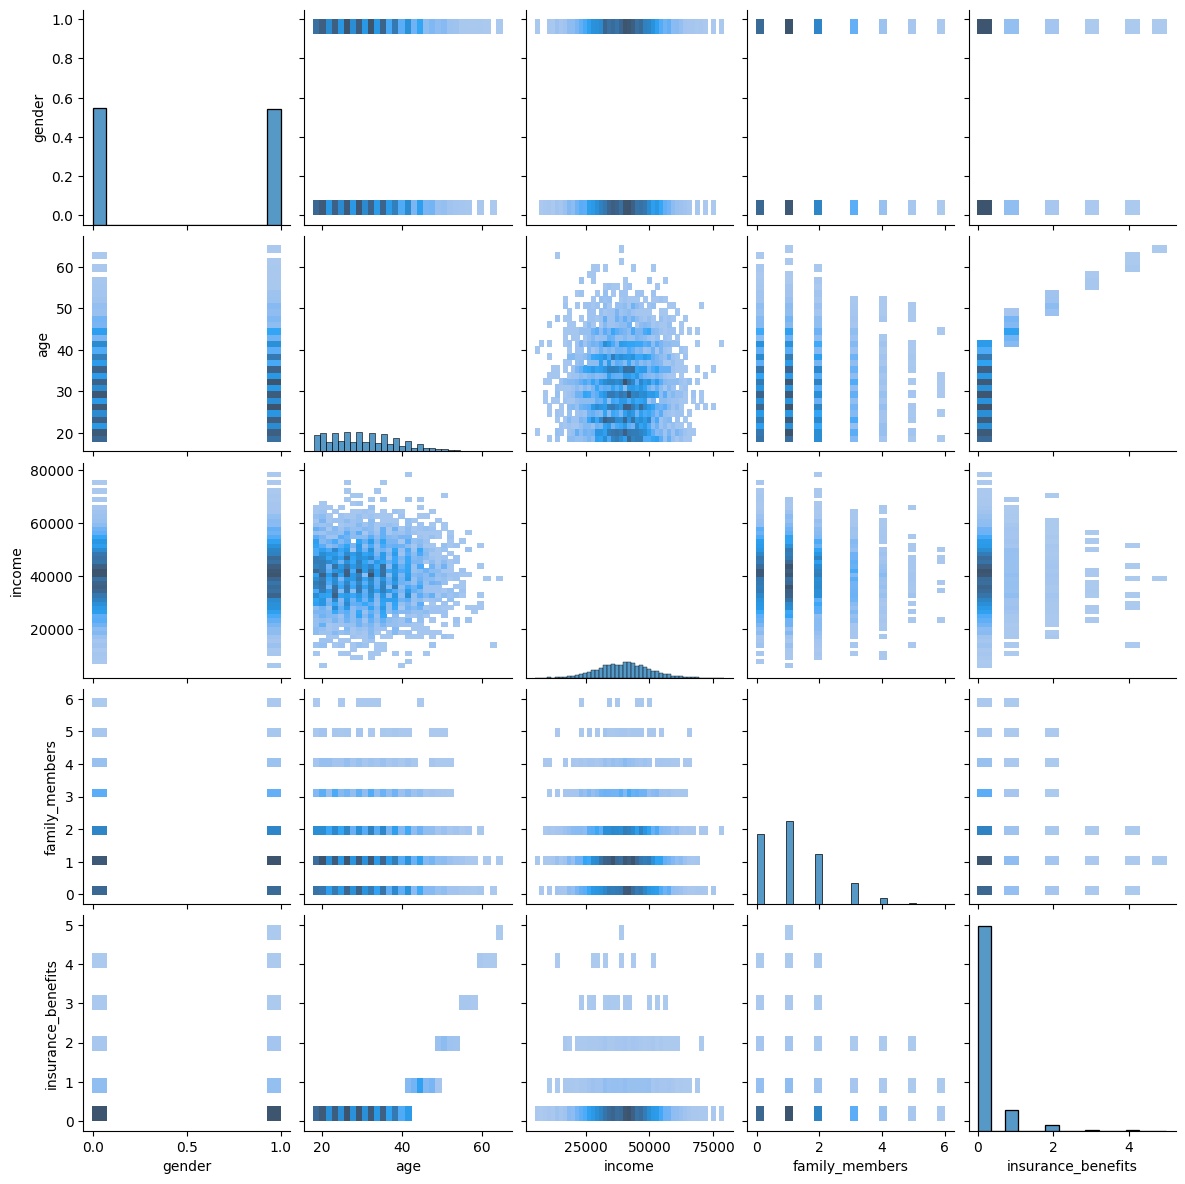

In [14]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, it is a bit difficult to spot obvious groups (clusters) as it is difficult to combine several variables simultaneously (to analyze multivariate distributions). That's where LA and ML can be quite handy.

# Task 1. Similar Customers

In the language of ML, it is necessary to develop a procedure that returns k nearest neighbors (objects) for a given object based on the distance between the objects.

You may want to review the following lessons (chapter -> lesson)
- Distance Between Vectors -> Euclidean Distance
- Distance Between Vectors -> Manhattan Distance

To solve the task, we can try different distance metrics.

Write a function that returns k nearest neighbors for an $n^{th}$ object based on a specified distance metric. The number of received insurance benefits should not be taken into account for this task. 

You can use a ready implementation of the kNN algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) or use your own.

Test it for four combination of two cases
- Scaling
  - the data is not scaled
  - the data is scaled with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler
- Distance Metrics
  - Euclidean
  - Manhattan

Answer these questions:
- Does the data being not scaled affect the kNN algorithm? If so, how does that appear?
- How similar are the results using the Manhattan distance metric (regardless of the scaling)?

In [15]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [16]:
def get_knn(df, n, k, metric):
    
    """
    Returns k nearest neighbors

    :param df: pandas DataFrame used to find similar objects within
    :param n: object no for which the nearest neighbours are looked for
    :param k: the number of the nearest neighbours to return
    :param metric: name of distance metric
    """

    nbrs = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k, metric=metric)
    X = df[feature_names]
    nbrs.fit(X, df.index)
    nbrs_distances, nbrs_indices = nbrs.kneighbors([X.iloc[n]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

Scaling the data.

In [17]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [18]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
1512,1.0,0.415385,0.465823,0.166667,0
3470,0.0,0.384615,0.627848,0.000000,0
3546,1.0,0.369231,0.546835,0.166667,0
4025,1.0,0.492308,0.339241,0.500000,0
1944,1.0,0.430769,0.563291,0.166667,0


Now, let's get similar records for a given one for every combination

In [19]:
score_original_euclidean = get_knn(df, 42, 15, 'euclidean')
score_original_euclidean

,gender,age,income,family_members,insurance_benefits,distance
42,1,42,69200.0,0,1,0.000000
4356,0,45,69400.0,1,1,200.027498
3914,0,33,68900.0,1,0,300.138301
2943,1,36,68500.0,1,0,700.026428
3667,1,28,70000.0,2,0,800.124990
2901,0,27,68400.0,0,0,800.141238
2056,1,21,68000.0,2,0,1200.185402
3279,1,50,70500.0,0,2,1300.024615
1863,1,30,70600.0,0,0,1400.051428
424,1,30,67700.0,0,0,1500.047999


In [20]:
score_scaled_euclidean = get_knn(df_scaled, 42, 5, 'euclidean')
score_scaled_euclidean

,gender,age,income,family_members,insurance_benefits,distance
42,1.0,0.646154,0.875949,0.0,1,0.000000
213,1.0,0.661538,0.763291,0.0,1,0.113704
3279,1.0,0.769231,0.892405,0.0,2,0.124172
771,1.0,0.600000,0.758228,0.0,0,0.126446
2833,1.0,0.630769,0.739241,0.0,0,0.137572


In [21]:
score_original_manhatten = get_knn(df, 42, 15, 'cityblock')
score_original_manhatten

,gender,age,income,family_members,insurance_benefits,distance
42,1,42,69200.0,0,1,0.0
4356,0,45,69400.0,1,1,205.0
3914,0,33,68900.0,1,0,311.0
2943,1,36,68500.0,1,0,707.0
2901,0,27,68400.0,0,0,816.0
3667,1,28,70000.0,2,0,816.0
2056,1,21,68000.0,2,0,1223.0
3279,1,50,70500.0,0,2,1308.0
1863,1,30,70600.0,0,0,1412.0
424,1,30,67700.0,0,0,1512.0


In [22]:
score_scaled_manhatten = get_knn(df_scaled, 42, 5, 'cityblock')
score_scaled_manhatten

,gender,age,income,family_members,insurance_benefits,distance
42,1.0,0.646154,0.875949,0.0,1,0.000000
213,1.0,0.661538,0.763291,0.0,1,0.128043
3279,1.0,0.769231,0.892405,0.0,2,0.139533
2833,1.0,0.630769,0.739241,0.0,0,0.152093
771,1.0,0.600000,0.758228,0.0,0,0.163875


Answers to the questions

**Does the data being not scaled affect the kNN algorithm? If so, how does that appear?** 

Yes, not scaling the data significantly affects the kNN algorithm, especially when using the Euclidean distance metric. Features with larger numeric ranges (e.g., income) dominate the distance calculations, making smaller-range features (e.g., gender, family members) less influential. This results in nearest neighbors being determined mostly by income rather than other factors. When the data is scaled, all features contribute equally to distance computations, leading to a more balanced similarity measure.


**How similar are the results using the Manhattan distance metric (regardless of the scaling)?** 

The Manhattan distance metric is less affected by scaling than the Euclidean distance metric. This is because Manhattan distance sums absolute differences between feature values rather than squaring them. As a result, even when data is not scaled, Manhattan distance still maintains a reasonable ranking of neighbors. However, scaling still ensures that all features contribute fairly to the similarity measurement.

# Task 2. Is Customer Likely to Receive Insurance Benefit?

In terms of machine learning we can look at this like a binary classification task.

With `insurance_benefits` being more than zero as the target, evaluate whether the kNN classification approach can do better than a dummy model.

Instructions:
- Build a KNN-based classifier and measure its quality with the F1 metric for k=1..10 for both the original data and the scaled one. That'd be interesting to see how k may influece the evaluation metric, and whether scaling the data makes any difference. You can use a ready implemention of the kNN classification algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) or use your own.
- Build the dummy model which is just random for this case. It should return "1" with some probability. Let's test the model with four probability values: 0, the probability of paying any insurance benefit, 0.5, 1.

The probability of paying any insurance benefit can be defined as

$$
P\{\text{insurance benefit received}\}=\frac{\text{number of clients received any insurance benefit}}{\text{total number of clients}}.
$$

Split the whole data in the 70:30 proportion for the training/testing parts.

In [23]:
# calculate the target
df['insurance_benefits_received'] = df['insurance_benefits'].apply(lambda x: 0 if x == 0 else 1)
df.sample(10)

,gender,age,income,family_members,insurance_benefits,insurance_benefits_received
3357,1,25,37300.0,0,0,0
2520,0,23,25100.0,0,0,0
316,0,20,39800.0,2,0,0
92,1,25,26700.0,1,0,0
4531,1,40,27200.0,0,0,0
2504,0,26,34100.0,0,0,0
3075,1,23,52300.0,3,0,0
3248,1,42,42200.0,0,1,1
4373,0,26,57100.0,1,0,0
376,1,32,41200.0,3,0,0


In [24]:
# check for the class imbalance with value_counts()

df['insurance_benefits_received'].value_counts()

0    4284
1     563
Name: insurance_benefits_received, dtype: int64

In [25]:
# Original dataset
X = df.drop(['insurance_benefits', 'insurance_benefits_received'], axis=1)
y = df[['insurance_benefits_received']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaled dataset
transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(X_train.to_numpy())
def max_abs_scaler(data):
    data_scaled = data.copy()
    data_scaled.loc[:, :] = transformer_mas.transform(data.to_numpy())
    return data_scaled
X_train_scaled = max_abs_scaler(X_train)
X_test_scaled = max_abs_scaler(X_test)

In [26]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# if you have an issue with the following line, restart the kernel and run the notebook again
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)

In [27]:
# generating output of a random model

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [28]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'The probability: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, df.shape[0]) 
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

The probability: 0.00
F1: 0.00
Confusion Matrix
[[0.88384568 0.        ]
 [0.11615432 0.        ]]

The probability: 0.12
F1: 0.13
Confusion Matrix
[[0.78502166 0.09882401]
 [0.1017124  0.01444192]]

The probability: 0.50
F1: 0.19
Confusion Matrix
[[0.44873117 0.4351145 ]
 [0.05921188 0.05694244]]

The probability: 1.00
F1: 0.21
Confusion Matrix
[[0.         0.88384568]
 [0.         0.11615432]]



In [29]:
def knn_train_eval(X_train, y_train, X_test):
    for i in range(1, 11):
        print("K = ", i)
        knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        eval_classifier(y_test, y_pred)

In [30]:
# Now you can call the function
knn_train_eval(X_train, y_train, X_test)


K =  1
F1: 0.66
Confusion Matrix
[[0.86735395 0.02405498]
 [0.04261168 0.06597938]]
K =  2
F1: 0.47
Confusion Matrix
[[0.88522337 0.00618557]
 [0.07353952 0.03505155]]
K =  3
F1: 0.45
Confusion Matrix
[[0.87285223 0.0185567 ]
 [0.07147766 0.0371134 ]]
K =  4
F1: 0.16
Confusion Matrix
[[0.88934708 0.00206186]
 [0.09896907 0.00962199]]
K =  5
F1: 0.17
Confusion Matrix
[[0.88659794 0.004811  ]
 [0.09828179 0.01030928]]
K =  6


/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pl

F1: 0.08
Confusion Matrix
[[8.90721649e-01 6.87285223e-04]
 [1.03780069e-01 4.81099656e-03]]
K =  7
F1: 0.11
Confusion Matrix
[[8.90721649e-01 6.87285223e-04]
 [1.02405498e-01 6.18556701e-03]]
K =  8
F1: 0.02
Confusion Matrix
[[0.89140893 0.        ]
 [0.10721649 0.00137457]]
K =  9
F1: 0.04
Confusion Matrix
[[0.89140893 0.        ]
 [0.10652921 0.00206186]]
K =  10
F1: 0.02
Confusion Matrix
[[0.89140893 0.        ]
 [0.10721649 0.00137457]]


/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pl

In [31]:
knn_train_eval(X_train_scaled, y_train, X_test_scaled)

K =  1
F1: 0.95
Confusion Matrix
[[0.88453608 0.00687285]
 [0.004811   0.10378007]]
K =  2


/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


F1: 0.95
Confusion Matrix
[[8.90721649e-01 6.87285223e-04]
 [9.62199313e-03 9.89690722e-02]]
K =  3
F1: 0.95
Confusion Matrix
[[0.88728522 0.00412371]
 [0.00618557 0.1024055 ]]
K =  4
F1: 0.94
Confusion Matrix
[[0.89003436 0.00137457]
 [0.01099656 0.0975945 ]]
K =  5
F1: 0.95
Confusion Matrix
[[0.88728522 0.00412371]
 [0.00687285 0.10171821]]
K =  6


/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


F1: 0.94
Confusion Matrix
[[0.88934708 0.00206186]
 [0.01030928 0.09828179]]
K =  7
F1: 0.96
Confusion Matrix
[[0.88797251 0.00343643]
 [0.00618557 0.1024055 ]]
K =  8


/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


F1: 0.94
Confusion Matrix
[[0.89003436 0.00137457]
 [0.01030928 0.09828179]]
K =  9
F1: 0.94
Confusion Matrix
[[0.88797251 0.00343643]
 [0.00824742 0.10034364]]
K =  10
F1: 0.95
Confusion Matrix
[[8.90721649e-01 6.87285223e-04]
 [1.03092784e-02 9.82817869e-02]]


/opt/conda/envs/python3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


# Task 3. Regression (with Linear Regression)

With `insurance_benefits` as the target, evaluate what RMSE would be for a Linear Regression model.

Build your own implementation of LR. For that, recall how the linear regression task's solution is formulated in terms of LA. Check RMSE for both the original data and the scaled one. Can you see any difference in RMSE between these two cases?

Let's denote
- $X$ — feature matrix, each row is a case, each column is a feature, the first column consists of unities
- $y$ — target (a vector)
- $\hat{y}$ — estimated tagret (a vector)
- $w$ — weight vector

The task of linear regression in the language of matrices can be formulated as

$$
y = Xw
$$

The training objective then is to find such $w$ that it would minimize the L2-distance (MSE) between $Xw$ and $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

It appears that there is analytical solution for the above:

$$
w = (X^T X)^{-1} X^T y
$$

The formula above can be used to find the weights $w$ and the latter can be used to calculate predicted values

$$
\hat{y} = X_{val}w
$$

Split the whole data in the 70:30 proportion for the training/validation parts. Use the RMSE metric for the model evaluation.

In [32]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(np.dot(X2.T, X2)).dot(X2.T).dot(y)

    def predict(self, X):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2.dot(self.weights)
        
        return y_pred

In [33]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    

In [34]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.54087854e-01  3.58373221e-02  8.48333599e-04  2.61002372e-07
 -1.61481354e-02]
RMSE: 0.36
R2: 0.66


In [35]:
import math
import sklearn.metrics

def eval_regressor(y_true, y_pred):
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')

    r2_score_value = sklearn.metrics.r2_score(y_true, y_pred)
    if r2_score_value < 0:
        r2_score_value = 0  # Ensure non-negative input for sqrt
    
    r2_score = math.sqrt(r2_score_value)
    print(f'R2: {r2_score:.2f}')


In [36]:
lr_scaled = MyLinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
print(lr_scaled.weights)

scaled_y_test_pred = lr_scaled.predict(X_test_scaled)
eval_regressor(y_test, scaled_y_test_pred)


[-9.54087854e-01  8.48333599e-04  2.22191397e+00  2.06191874e-02
 -9.68888122e-02]
RMSE: 0.36
R2: 0.66


# Task 4. Obfuscating Data

It best to obfuscate data by multiplying the numerical features (remember, they can be seen as the matrix $X$) by an invertible matrix $P$. 

$$
X' = X \times P
$$

Try to do that and check how the features' values will look like after the transformation. By the way, the intertible property is important here so make sure that $P$ is indeed invertible.

You may want to review the 'Matrices and Matrix Operations -> Matrix Multiplication' lesson to recall the rule of matrix multiplication and its implementation with NumPy.

In [37]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [38]:
X = df_pn.to_numpy()

Generating a random matrix $P$.

In [39]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Checking the matrix $P$ is invertible

In [40]:
try:
    inv = np.linalg.inv(P)
    print("The matrix P is invertible")
except np.linalg.LinAlgError:
    print("The matrix P isn't invertible")
    

The matrix P is invertible


Can you guess the customers' ages or income after the transformation?

No, after the transformation, it is not possible to directly guess customers' ages or income without knowing the matrix $P$. The obfuscation hides the original values while preserving data structure.

In [41]:
X3 = X.dot(P)

The new matrix consists of meaningless numbers. It can't be guessed only from the numbers.

Can you recover the original data from $X'$ if you know $P$? Try to check that with calculations by moving $P$ from the right side of the formula above to the left one. The rules of matrix multiplcation are really helpful here.

In [42]:
X_restored = X3.dot(np.linalg.inv(P))

If the matrix P is given, the original matrix X can be restored by the following formula


$X restored$ = $X$ x $P^{-1}$


Print all three cases for a few customers
- The original data
- The transformed one
- The reversed (recovered) one

In [43]:
print(f"""The original matrix:
{X[:5, :]}.

The transformed matrix:
{X3[:5, :]}.

The reversed matrix:
{X_restored[:5, :]}
""")

The original matrix:
[[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 [0.00e+00 2.10e+01 4.17e+04 2.00e+00]
 [1.00e+00 2.80e+01 2.61e+04 0.00e+00]].

The transformed matrix:
[[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 [ 5345.60393712 18803.22720286 15479.14837264 38663.06186284]
 [ 3347.17673462 11782.82928336  9699.99894205 24211.27337753]].

The reversed matrix:
[[ 1.00000000e+00  4.10000000e+01  4.96000000e+04  1.00000000e+00]
 [-4.47363596e-12  4.60000000e+01  3.80000000e+04  1.00000000e+00]
 [-2.51586878e-12  2.90000000e+01  2.10000000e+04  9.52452315e-13]
 [-4.84498208e-12  2.10000000e+01  4.17000000e+04  2.00000000e+00]
 [ 1.00000000e+00  2.80000000e+01  2.61000000e+04 -1.01990740e-13]]



You can probably see that some values are not exactly the same as they are in the original data. What might be the reason for that?

When we calculate float numbers with Python or Numpy, some extremely small numbers, e.g. -4.47e-12, may appear rather than 0 due to the data precision.

I'll use np.close()

## Proof That Data Obfuscation Can Work with LR

The regression task has been solved with linear regression in this project. Your next task is to prove _analytically_ that the given obfuscation method won't affect linear regression in terms of predicted values i.e. their values will remain the same. Can you believe that? Well, you don't have to, you should prove it!

So, the data is obfuscated and there is $X \times P$ instead of just $X$ now. Consequently, there are other weights $w_P$ as
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

How would $w$ and $w_P$ be linked if you simplify the formula for $w_P$ above? 

What would be predicted values with $w_P$? 

What does that mean for the quality of linear regression if you measure it with RMSE?

Check Appendix B Properties of Matrices in the end of the notebook. There are useful formulas in there!

No code is necessary in this section, only analytical explanation!

**Answer**

We've already known that the matrix $P$ and \( X^T X \) is invertible, and \( (P^T)^{-1} P^T = I \). However, $P$ must be invertible. Therefore, the formula:

$$
w_P = [(XP)^T XP]^{-1} (XP)^T y = [P^T X^T XP]^{-1} P^T X^T y = P^{-1} (X^T X)^{-1} (P^T)^{-1} P^T X^T y = P^{-1} (X^T X)^{-1} X^T y = P^{-1} w
$$

Now, we need to show that the predictions remain the same:

$$
\hat{y} = X w
$$

Substituting \( w_P = P^{-1} w \) into the prediction equation:

$$
\hat{y}_P = XP w_P = X P^{-1} w
$$

Since \( P^{-1} P = I \), we get:

$$
XP w_P = XP P^{-1} w = Xw
$$

Thus, we have shown that **predictions remain unchanged, meaning RMSE and R² scores will also stay the same**.


**Analytical proof**

# Analytical Proof

From the formula, we can see that the parameter matrix $w_P$  is a linear transformation of the original matrix $w$ based on the matrix $P$.

We can use the formula to prove it. However, no matter how the parameter matrix changes, the predictions won't change as well, therefore the RMSE and R² metrics won't change either.


## Test Linear Regression With Data Obfuscation

Now, let's prove Linear Regression can work computationally with the chosen obfuscation transformation.

Build a procedure or a class that runs Linear Regression optionally with the obfuscation. You can use either a ready implementation of Linear Regression from sciki-learn or your own.

Run Linear Regression for the original data and the obfuscated one, compare the predicted values and the RMSE, $R^2$ metric values. Is there any difference?

**Procedure**

- Create a square matrix $P$ of random numbers.
- Check that it is invertible. If not, repeat the first point until we get an invertible matrix.
- <! your comment here !>
- Use $XP$ as the new feature matrix

In [44]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))
try:
    inv = np.linalg.inv(P)
    print("The matrix P is invertible")
except np.linalg.LinAlgError:
    print("The matrix P isn't invertible")

The matrix P is invertible


In [45]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # adding the unities
        X = X.dot(P)
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(np.dot(X2.T, X2)).dot(X2.T).dot(y)

    def predict(self, X):
        
        # adding the unities
        X = X.dot(P)
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2.dot(self.weights)
        
        return y_pred

In [46]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-0.95408786 -0.00476774 -0.05677244  0.07719932 -0.00263797]
RMSE: 0.36
R2: 0.66


In [47]:
# Original dataset (without obfuscation)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr_orig = MyLinearRegression()
lr_orig.fit(X_train_orig, y_train)
y_test_pred_orig = lr_orig.predict(X_test_orig)

print("Results for Original Data:")
eval_regressor(y_test, y_test_pred_orig)

# Obfuscated dataset
X_train_obf, X_test_obf = X_train_orig.dot(P), X_test_orig.dot(P)  # Apply obfuscation

lr_obf = MyLinearRegression()
lr_obf.fit(X_train_obf, y_train)
y_test_pred_obf = lr_obf.predict(X_test_obf)

print("Results for Obfuscated Data:")
eval_regressor(y_test, y_test_pred_obf)


Results for Original Data:
RMSE: 0.36
R2: 0.66
Results for Obfuscated Data:
RMSE: 0.36
R2: 0.66


We now validate that Linear Regression produces the **same predictions** and **metric values** for both:
- The **original dataset**.
- The **obfuscated dataset** (transformed with $P$ .

This ensures that the obfuscation technique does **not** affect model performance.

The results from the real data proof that the prediction results won't change by data obfuscation

# Conclusions

In this project, I implemented a KNN classification model and a custom linear regression model on the dataset.


Based on the KNN technique, we could not only find similar vectors for a given vector, but we can also make classifications. The prediction results are influenced by the hyperparameter \( K \), but in the classification case, whether the data has been scaled plays a more important role.


On the other hand, for the regression task, feature scaling does not seem as important as in the classification task. I also applied two models with different distance algorithms, but the results were very close.


Additionally, for the sake of protecting customer privacy, it is important to de-identify customer personal information. The method is to multiply an invertible matrix to transform the original data into a meaningless format. This operation affects the parameter matrix, but it does not change the prediction results, as well as RMSE or $R^2$ metrics.


# Checklist

Type 'x' to check. Then press Shift+Enter.

- [x]  Jupyter Notebook is open
- [ ]  Code is error free
- [ ]  The cells are arranged in order of logic and execution
- [ ]  Task 1 has been performed
    - [ ]  There is the procedure that can return k similar customers for a given one
    - [ ]  The procedure is tested for all four proposed combinations
    - [ ]  The questions re the scaling/distances are answered
- [ ]  Task 2 has been performed
    - [ ]  The random classification model is built and tested for all for probability levels
    - [ ]  The kNN classification model is built and tested for both the original data and the scaled one, the F1 metric is calculated.
- [ ]  Task 3 has been performed
    - [ ]  The linear tegression solution is implemented with matrix operations.
    - [ ]  RMSE is calculated for the implemented solution.
- [ ]  Task 4 has been performed
    - [ ]  The data is obfuscated with a random and invertible matrix P
    - [ ]  The obfuscated data is recoved, few examples are printed out
    - [ ]  The analytical proof that the transformation does not affect RMSE is provided 
    - [ ]  The computational proof that the transformation does not affect RMSE is provided
- [ ]  Conclusions have been made

# Appendices 

## Appendix A: Writing Formulas in Jupyter Notebooks

You can write formulas in your Jupyter Notebook in a markup language provided by a high-quality publishing system called $\LaTeX$ (pronounced "Lah-tech"), and they will look like formulas in textbooks.

To put a formula in a text, put the dollar sign (\\$) before and after the formula's text e.g. $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

If a formula should be in its own paragraph, put the double dollar sign (\\$\\$) before and after the formula text e.g.

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

The markup language of [LaTeX](https://en.wikipedia.org/wiki/LaTeX) is very popular among people who use formulas in their articles, books and texts. It can be complex but its basics are easy. Check this two page [cheatsheet](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) for learning how to compose the most common formulas.

## Appendix B: Properties of Matrices

Matrices have many properties in Linear Algebra. A few of them are listed here which can help with the analytical proof in this project.

<table>
<tr>
<td>Distributivity</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Non-commutativity</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Associative property of multiplication</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Multiplicative identity property</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversivity of the transpose of a product of matrices,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>